**Task 01**

In [ ]:
import numpy as np
import unittest

def simulate_once(seed=123):
    np.random.seed(seed)

    rand_float = np.random.rand()

    dice1 = np.random.randint(1, 7)
    dice2 = np.random.randint(1, 7)

    step = 50
    print(f"Before throw step = {step}")

    dice = np.random.randint(1, 7)

    if dice in (1, 2):
        step -= 1   
    elif dice in (3, 4, 5):
        step += 1
    else:
        extra = np.random.randint(1, 7)
        step += extra

    print(f"After throw dice = {dice}")
    print(f"After throw step = {step}")

    return rand_float, dice1, dice2, dice, step


class TestRandomSim(unittest.TestCase):
    def test_types_and_ranges(self):
        rand_float, d1, d2, dice, step = simulate_once(seed=123)
        self.assertTrue(0.0 <= rand_float < 1.0)
        self.assertIn(d1, range(1, 7))
        self.assertIn(d2, range(1, 7))
        self.assertIn(dice, range(1, 7))
        self.assertTrue(0 < step)


if __name__ == "__main__":
    rand_float, d1, d2, dice, step = simulate_once(seed=123)
    print(f"Random float: {rand_float}")
    print(f"Random integer 1: {d1}")
    print(f"Random integer 2: {d2}")
    unittest.main(argv=["first-arg-is-ignored"], exit=False)


...

Before throw step = 50
After throw dice = 3
After throw step = 51
Random float: 0.6964691855978616
Random integer 1: 3
Random integer 2: 5


.......
----------------------------------------------------------------------
Ran 10 tests in 0.512s

OK


Before throw step = 50
After throw dice = 3
After throw step = 51


**Task 02**

In [ ]:
import numpy as np
import unittest


def random_walk_100(seed=123):
    np.random.seed(seed)
    random_walk = [0]

    for _ in range(100):
        step = random_walk[-1]

        dice = np.random.randint(1, 7)

        if dice in (1, 2):
            step -= 1
        elif dice in (3, 4, 5):
            step += 1
        else:
            extra = np.random.randint(1, 7)
            step += extra

        random_walk.append(step)

    # Answer:
    # The walk can go below 0.

    return random_walk


class TestRandomWalk(unittest.TestCase):
    def test_length_and_start(self):
        walk = random_walk_100(seed=123)
        self.assertEqual(len(walk), 101)
        self.assertEqual(walk[0], 0)

    def test_integers(self):
        walk = random_walk_100(seed=123)
        self.assertTrue(all(isinstance(s, int) for s in walk))


if __name__ == "__main__":
    walk = random_walk_100(seed=123)
    print(walk)
    unittest.main(argv=["first-arg-is-ignored"], exit=False)


...
----------------------------------------------------------------------
Ran 3 tests in 0.005s

OK


[0, 3, 4, 5, 4, 5, 6, 7, 6, 5, 4, 3, 2, 1, 0, -1, 0, 5, 4, 3, 4, 3, 4, 5, 6, 7, 8, 7, 8, 7, 8, 9, 10, 11, 10, 14, 15, 14, 15, 14, 15, 16, 17, 18, 19, 20, 21, 24, 25, 26, 27, 32, 33, 37, 38, 37, 38, 39, 38, 39, 40, 42, 43, 44, 43, 42, 43, 44, 43, 42, 43, 44, 46, 45, 44, 45, 44, 45, 46, 47, 49, 48, 49, 50, 51, 52, 53, 52, 51, 52, 51, 52, 53, 52, 55, 56, 57, 58, 57, 58, 59]
Before throw step = 50
After throw dice = 3
After throw step = 51


**Task 03**

In [ ]:
import numpy as np
import unittest

def random_walk_100_fixed(seed=123):
    np.random.seed(seed)
    random_walk = [0]

    for _ in range(100):
        step = random_walk[-1]
        dice = np.random.randint(1, 7)

        if dice <= 2:
            # BUG FIX: don't go below 0
            step = max(0, step - 1)
        elif dice <= 5:
            step += 1
        else:
            step += np.random.randint(1, 7)

        random_walk.append(step)


    return random_walk


class TestRandomWalkFixed(unittest.TestCase):
    def test_never_negative(self):
        walk = random_walk_100_fixed(seed=123)
        self.assertTrue(all(step >= 0 for step in walk))

    def test_length(self):
        walk = random_walk_100_fixed(seed=123)
        self.assertEqual(len(walk), 101)


if __name__ == "__main__":
    walk = random_walk_100_fixed(seed=123)
    print(walk)
    unittest.main(argv=["first-arg-is-ignored"], exit=False)

.......
----------------------------------------------------------------------
Ran 7 tests in 0.016s

OK


[0, 3, 4, 5, 4, 5, 6, 7, 6, 5, 4, 3, 2, 1, 0, 0, 1, 6, 5, 4, 5, 4, 5, 6, 7, 8, 9, 8, 9, 8, 9, 10, 11, 12, 11, 15, 16, 15, 16, 15, 16, 17, 18, 19, 20, 21, 22, 25, 26, 27, 28, 33, 34, 38, 39, 38, 39, 40, 39, 40, 41, 43, 44, 45, 44, 43, 44, 45, 44, 43, 44, 45, 47, 46, 45, 46, 45, 46, 47, 48, 50, 49, 50, 51, 52, 53, 54, 53, 52, 53, 52, 53, 54, 53, 56, 57, 58, 59, 58, 59, 60]
Before throw step = 50
After throw dice = 3
After throw step = 51


**Task 04**

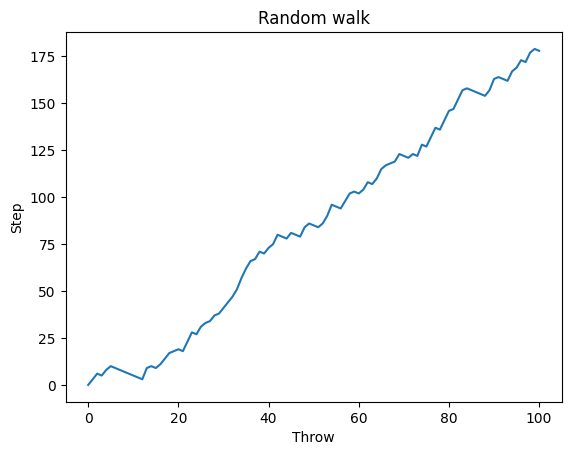

.......
----------------------------------------------------------------------
Ran 7 tests in 0.021s

OK


Before throw step = 50
After throw dice = 3
After throw step = 51


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import unittest


def random_walk_100_fixed(seed=123):
    np.random.seed(seed)
    random_walk = [0]

    for _ in range(100):
        step = random_walk[-1]
        dice = np.random.randint(1, 7)

        if dice <= 2:
            step = max(0, step - 1)
        else:
            step += np.random.randint(1, 7)

        random_walk.append(step)

    return random_walk


def plot_random_walk(walk):
    plt.figure()
    plt.plot(walk)
    plt.title("Random walk")
    plt.xlabel("Throw")
    plt.ylabel("Step")
    plt.show()


class TestRandomWalkPlot(unittest.TestCase):
    def test_walk_properties(self):
        walk = random_walk_100_fixed(seed=123)
        self.assertEqual(len(walk), 101)
        self.assertEqual(walk[0], 0)
        self.assertTrue(all(w >= 0 for w in walk))


if __name__ == "__main__":
    walk = random_walk_100_fixed(seed=123)
    plot_random_walk(walk)
    unittest.main(argv=["first-arg-is-ignored"], exit=False)


**Task 05**

In [ ]:
import numpy as np
import unittest


def single_random_walk(seed=None):
    if seed is not None:
        np.random.seed(seed)

    random_walk = [0]
    for _ in range(100):
        step = random_walk[-1]
        dice = np.random.randint(1, 7)

        if dice <= 2:
            step = max(0, step - 1)
        elif dice <= 5:
            step += 1
        else:
            step += np.random.randint(1, 7)

        random_walk.append(step)

    return random_walk


def simulate_multiple_walks(n_walks=5, seed=123):
    np.random.seed(seed)
    all_walks = []

    for _ in range(n_walks):
        random_walk = [0]
        for _ in range(100):
            step = random_walk[-1]
            dice = np.random.randint(1, 7)

            if dice <= 2:
                step = max(0, step - 1)
            elif dice <= 5:
                step += 1
            else:
                step += np.random.randint(1, 7)

            random_walk.append(step)

        all_walks.append(random_walk)


    return all_walks


class TestAllWalks(unittest.TestCase):
    def test_shape(self):
        all_walks = simulate_multiple_walks(n_walks=5, seed=123)
        self.assertEqual(len(all_walks), 5)
        self.assertTrue(all(len(w) == 101 for w in all_walks))
        self.assertTrue(all(w[0] == 0 for w in all_walks))


if __name__ == "__main__":
    walks = simulate_multiple_walks(n_walks=5, seed=123)
    print(walks)
    unittest.main(argv=["first-arg-is-ignored"], exit=False)

.......
----------------------------------------------------------------------
Ran 7 tests in 0.016s

OK


[[0, 3, 4, 5, 4, 5, 6, 7, 6, 5, 4, 3, 2, 1, 0, 0, 1, 6, 5, 4, 5, 4, 5, 6, 7, 8, 9, 8, 9, 8, 9, 10, 11, 12, 11, 15, 16, 15, 16, 15, 16, 17, 18, 19, 20, 21, 22, 25, 26, 27, 28, 33, 34, 38, 39, 38, 39, 40, 39, 40, 41, 43, 44, 45, 44, 43, 44, 45, 44, 43, 44, 45, 47, 46, 45, 46, 45, 46, 47, 48, 50, 49, 50, 51, 52, 53, 54, 53, 52, 53, 52, 53, 54, 53, 56, 57, 58, 59, 58, 59, 60], [0, 4, 3, 2, 4, 3, 4, 6, 7, 8, 13, 12, 13, 14, 15, 16, 17, 16, 21, 22, 23, 24, 23, 22, 21, 20, 19, 20, 21, 22, 28, 27, 26, 25, 26, 27, 28, 27, 28, 29, 28, 33, 34, 33, 32, 31, 30, 31, 30, 29, 31, 32, 35, 36, 38, 39, 40, 41, 40, 39, 40, 41, 42, 43, 42, 43, 44, 45, 48, 49, 50, 49, 50, 49, 50, 51, 52, 56, 55, 54, 55, 56, 57, 56, 57, 56, 57, 59, 64, 63, 64, 65, 66, 67, 68, 69, 68, 69, 70, 71, 73], [0, 2, 1, 2, 3, 6, 5, 6, 5, 6, 7, 8, 7, 8, 7, 8, 9, 11, 10, 9, 10, 11, 10, 12, 13, 14, 15, 16, 17, 18, 17, 18, 19, 24, 25, 24, 23, 22, 21, 22, 23, 24, 29, 30, 29, 30, 31, 32, 33, 34, 35, 34, 33, 34, 33, 39, 38, 39, 38, 39, 38, 3

**Task 06**

[[0, 3, 4, 5, 4, 5, 6, 7, 6, 5, 4, 3, 2, 1, 0, 0, 1, 6, 5, 4, 5, 4, 5, 6, 7, 8, 9, 8, 9, 8, 9, 10, 11, 12, 11, 15, 16, 15, 16, 15, 16, 17, 18, 19, 20, 21, 22, 25, 26, 27, 28, 33, 34, 38, 39, 38, 39, 40, 39, 40, 41, 43, 44, 45, 44, 43, 44, 45, 44, 43, 44, 45, 47, 46, 45, 46, 45, 46, 47, 48, 50, 49, 50, 51, 52, 53, 54, 53, 52, 53, 52, 53, 54, 53, 56, 57, 58, 59, 58, 59, 60], [0, 4, 3, 2, 4, 3, 4, 6, 7, 8, 13, 12, 13, 14, 15, 16, 17, 16, 21, 22, 23, 24, 23, 22, 21, 20, 19, 20, 21, 22, 28, 27, 26, 25, 26, 27, 28, 27, 28, 29, 28, 33, 34, 33, 32, 31, 30, 31, 30, 29, 31, 32, 35, 36, 38, 39, 40, 41, 40, 39, 40, 41, 42, 43, 42, 43, 44, 45, 48, 49, 50, 49, 50, 49, 50, 51, 52, 56, 55, 54, 55, 56, 57, 56, 57, 56, 57, 59, 64, 63, 64, 65, 66, 67, 68, 69, 68, 69, 70, 71, 73], [0, 2, 1, 2, 3, 6, 5, 6, 5, 6, 7, 8, 7, 8, 7, 8, 9, 11, 10, 9, 10, 11, 10, 12, 13, 14, 15, 16, 17, 18, 17, 18, 19, 24, 25, 24, 23, 22, 21, 22, 23, 24, 29, 30, 29, 30, 31, 32, 33, 34, 35, 34, 33, 34, 33, 39, 38, 39, 38, 39, 38, 3

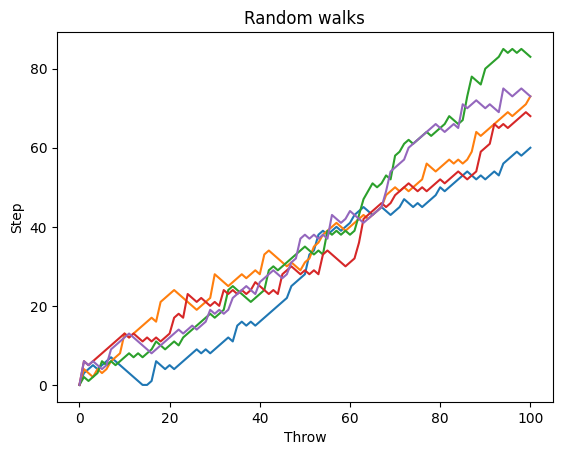

........
----------------------------------------------------------------------
Ran 8 tests in 0.036s

OK


Before throw step = 50
After throw dice = 3
After throw step = 51


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import unittest


def simulate_multiple_walks(n_walks=5, seed=123):
    np.random.seed(seed)
    all_walks = []

    for _ in range(n_walks):
        random_walk = [0]
        for _ in range(100):
            step = random_walk[-1]
            dice = np.random.randint(1, 7)

            if dice <= 2:
                step = max(0, step - 1)
            elif dice <= 5:
                step += 1
            else:
                step += np.random.randint(1, 7)

            random_walk.append(step)

        all_walks.append(random_walk)

    return all_walks


def plot_all_walks(all_walks):
    all_walks_np = np.array(all_walks)
    all_walks_np = all_walks_np.T

    plt.figure()
    plt.plot(all_walks_np)
    plt.title("Random walks")
    plt.xlabel("Throw")
    plt.ylabel("Step")
    plt.show()


class TestAllWalksPlot(unittest.TestCase):
    def test_array_shape(self):
        all_walks = simulate_multiple_walks(n_walks=5, seed=123)
        arr = np.array(all_walks)
        self.assertEqual(arr.shape[0], 5)
        self.assertEqual(arr.shape[1], 101)


if __name__ == "__main__":
    walks = simulate_multiple_walks(n_walks=5, seed=123)
    print(walks)          # all_walks
    plot_all_walks(walks)
    unittest.main(argv=["first-arg-is-ignored"], exit=False)


**Task 07**

[[0, 3, 2, 3, 2, 1, 0, 1, 2, 3, 4, 5, 4, 3, 4, 3, 4, 5, 6, 7, 8, 9, 10, 11, 15, 16, 15, 17, 16, 17, 18, 17, 18, 19, 21, 22, 23, 22, 23, 24, 23, 24, 25, 26, 30, 32, 34, 39, 40, 41, 0, 1, 2, 1, 0, 1, 7, 6, 5, 6, 7, 12, 11, 10, 9, 0, 1, 3, 4, 3, 4, 5, 6, 7, 6, 7, 11, 10, 11, 10, 9, 8, 7, 8, 9, 10, 11, 13, 14, 13, 12, 13, 14, 15, 17, 18, 17, 18, 19, 18, 19], [0, 5, 4, 3, 4, 5, 6, 7, 8, 9, 8, 14, 13, 14, 18, 22, 24, 26, 29, 30, 29, 30, 31, 32, 31, 32, 38, 37, 38, 39, 41, 40, 41, 47, 48, 49, 50, 49, 48, 49, 50, 49, 53, 52, 53, 54, 55, 59, 60, 59, 61, 60, 59, 60, 59, 58, 59, 64, 63, 62, 66, 69, 70, 72, 73, 72, 71, 72, 73, 72, 71, 76, 77, 78, 77, 76, 77, 78, 84, 85, 86, 87, 88, 87, 86, 87, 88, 87, 86, 87, 88, 87, 88, 89, 90, 89, 90, 91, 90, 93, 94], [0, 0, 1, 2, 4, 3, 2, 3, 7, 8, 9, 12, 13, 14, 13, 12, 18, 19, 18, 17, 18, 19, 18, 19, 24, 25, 31, 37, 39, 40, 46, 45, 46, 45, 46, 48, 49, 48, 49, 53, 52, 51, 52, 53, 54, 53, 52, 53, 52, 51, 52, 51, 52, 53, 52, 53, 54, 55, 56, 55, 54, 55, 58, 59, 60

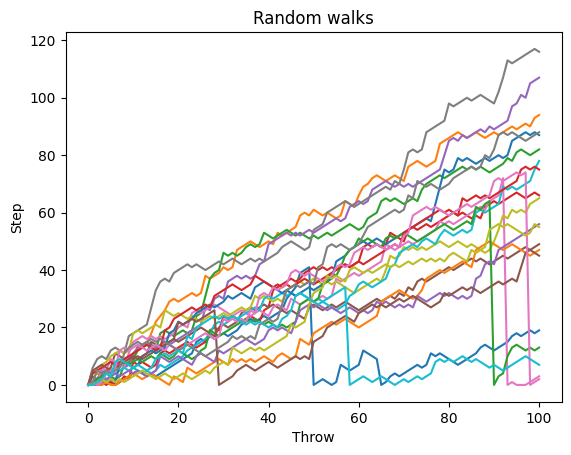

.........
----------------------------------------------------------------------
Ran 9 tests in 0.044s

OK


Before throw step = 50
After throw dice = 3
After throw step = 51


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import unittest


def simulate_multiple_walks_clumsy(n_walks=20, seed=123):
    np.random.seed(seed)
    all_walks = []

    for _ in range(n_walks):
        random_walk = [0]

        for _ in range(100):
            step = random_walk[-1]
            dice = np.random.randint(1, 7)

            if dice <= 2:
                step = max(0, step - 1)
            elif dice <= 5:
                step += 1
            else:
                step += np.random.randint(1, 7)

            # Clumsiness: 0.5% chance to fall back to 0
            if np.random.rand() <= 0.005:
                step = 0

            random_walk.append(step)

        all_walks.append(random_walk)

    return all_walks


def plot_clumsy_walks(all_walks):
    all_walks_np = np.array(all_walks).T

    plt.figure()
    plt.plot(all_walks_np)
    plt.title("Random walks")
    plt.xlabel("Throw")
    plt.ylabel("Step")
    plt.show()


class TestClumsyWalks(unittest.TestCase):
    def test_shape_and_nonnegative(self):
        walks = simulate_multiple_walks_clumsy(n_walks=20, seed=123)
        arr = np.array(walks)
        self.assertEqual(arr.shape[0], 20)
        self.assertEqual(arr.shape[1], 101)
        self.assertTrue((arr >= 0).all())


if __name__ == "__main__":
    walks = simulate_multiple_walks_clumsy(n_walks=20, seed=123)
    print(walks)
    plot_clumsy_walks(walks)
    unittest.main(argv=["first-arg-is-ignored"], exit=False)


**Task 08**

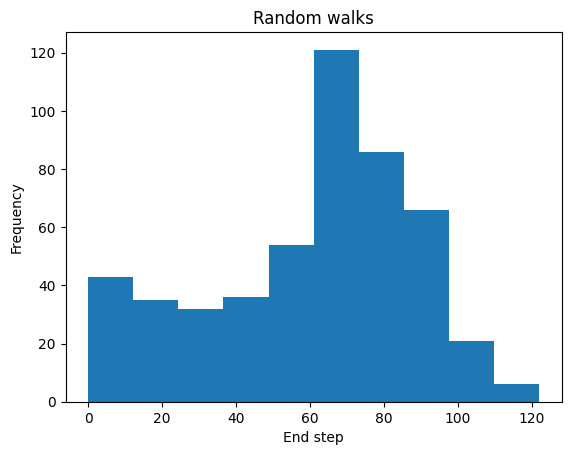

Odds of reaching at least 60 steps: 60.8%


F
FAIL: test_ends_length (__main__.TestEndSteps.test_ends_length)
----------------------------------------------------------------------
Traceback (most recent call last):
  File "/var/folders/jz/l8bn524159vcxdj4xb2c45c00000gn/T/ipykernel_32726/2811158491.py", line 56, in test_ends_length
    self.assertEqual(all_walks.shape, 500, 101)
    ~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: (500, 101) != 500 : 101

----------------------------------------------------------------------
Ran 1 test in 0.270s

FAILED (failures=1)


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import unittest


def simulate_multiple_walks_clumsy(n_walks=500, seed=123):
    np.random.seed(seed)
    all_walks = []

    for _ in range(n_walks):
        random_walk = [0]

        for _ in range(100):
            step = random_walk[-1]
            dice = np.random.randint(1, 7)

            if dice <= 2:
                step = max(0, step - 1)
            elif dice <= 5:
                step += 1
            else:
                step += np.random.randint(1, 7)

            if np.random.rand() <= 0.005:
                step = 0

            random_walk.append(step)

        all_walks.append(random_walk)

    return np.array(all_walks)


def plot_end_steps_and_odds():
    all_walks = simulate_multiple_walks_clumsy(n_walks=500, seed=123)
    ends = all_walks[:, -1]

    prob_reach_60 = np.mean(ends >= 60)

    plt.figure()
    plt.hist(ends, bins=10)
    plt.title("Random walks")
    plt.xlabel("End step")
    plt.ylabel("Frequency")
    plt.show()

    # Odds of reaching at least 60 steps are about 60.8%.
    print(f"Odds of reaching at least 60 steps: {prob_reach_60 * 100:.1f}%")

    return prob_reach_60, ends


class TestEndSteps(unittest.TestCase):
    def test_ends_length(self):
        all_walks = simulate_multiple_walks_clumsy(n_walks=500, seed=123)
        self.assertEqual(all_walks.shape, 500, 101)


if __name__ == "__main__":
    prob, ends = plot_end_steps_and_odds()
    unittest.main(argv=["first-arg-is-ignored"], exit=False)